# Data Analysis and Preparation

In [1]:
# imports

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, TwoSlopeNorm


# 1. Understand datasets

* Explore each of the datasets, their features, distributions, null values

In [2]:
churn_status = pd.read_csv('./data/Churn_Status.csv')
customer_demographics = pd.read_csv('./data/Customer_Demographics.csv')
customer_service = pd.read_csv('./data/Customer_Service.csv')
online_activity = pd.read_csv('./data/Online_Activity.csv')
transaction_history = pd.read_csv('./data/Transaction_History.csv')

customer_datasets = {"Customer Demographics": customer_demographics, "Customer Service": customer_service, "Online Activity": online_activity, "Transaction History": transaction_history}

In [3]:
for name, df in customer_datasets.items():
    print("Dataset name: ", name)
    dup_ids = df["CustomerID"].duplicated().sum()
    print("Number of repeated CustomerIDs: ", dup_ids)
    print("Number of missing CustomerIDs: ", churn_status["CustomerID"].unique().shape[0] - df["CustomerID"].unique().shape[0])
    print(df.info())
    print("Example data: ")
    print(df.head(3))
    print("\n\n")

print("Dataset name: ", "Churn Status")
print(churn_status.info())
print("Example data: ")
print(churn_status.head(3))

Dataset name:  Customer Demographics
Number of repeated CustomerIDs:  0
Number of missing CustomerIDs:  0
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     1000 non-null   int64
 1   Age            1000 non-null   int64
 2   Gender         1000 non-null   str  
 3   MaritalStatus  1000 non-null   str  
 4   IncomeLevel    1000 non-null   str  
dtypes: int64(2), str(3)
memory usage: 39.2 KB
None
Example data: 
   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low



Dataset name:  Customer Service
Number of repeated CustomerIDs:  334
Number of missing CustomerIDs:  332
<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 5 columns):
 #   Column            Non-N

# 2. Feature Engineering

* Combine the 5 separate datasets into one
* Aggregate features into a single data point per customer:
    * Create transaction value metrics for customers - total number of transactions, average transaction amount, total transaction amount, monthly transaction frequency, number of unique product categories, spending volatility, days since last transaction, and customer tenure (days since first transaction)
    * Create customer service interaction metrics for customers - number, frequency, positive/negative sentiment (based on feedback type and resolved status), and days since last service interaction
    * Transform online activity features - last login date to days since last login

In [4]:
# Transaction value metrics
transaction_history['TransactionDate'] = pd.to_datetime(transaction_history['TransactionDate'])

txn_snapshot_date = transaction_history['TransactionDate'].max() + pd.Timedelta(days=1)
txn_dates = transaction_history.groupby('CustomerID')['TransactionDate'].agg(['min', 'max']).reset_index()

transaction_feat = (transaction_history.groupby('CustomerID')
                    .agg(NumTransactions=('TransactionID', 'count'),
                         AvgTransactionAmount=('AmountSpent', 'mean'),
                         TotalTransactionAmount=('AmountSpent', 'sum'),
                         NumUniqueProductCategories=('ProductCategory', 'nunique'),
                         SpendingVolatility=('AmountSpent', 'std'))
                    .reset_index()
                    .merge(txn_dates, on='CustomerID'))

# tenure = days since a customer's first transaction; days since last = days since their most recent one
transaction_feat['CustomerTenureDays'] = (txn_snapshot_date - transaction_feat['min']).dt.days
transaction_feat['DaysSinceLastTransaction'] = (txn_snapshot_date - transaction_feat['max']).dt.days
transaction_feat = transaction_feat.drop(columns=['min', 'max'])

# monthly transaction frequency, scaled by each customer's own tenure
transaction_feat['TransactionFrequency'] = (transaction_feat['NumTransactions']
                                             / (transaction_feat['CustomerTenureDays'] + 1) * 30)

transaction_feat['SpendingVolatility'] = transaction_feat['SpendingVolatility'].fillna(0)

# Customer service interaction metrics
customer_service['InteractionDate'] = pd.to_datetime(customer_service['InteractionDate'])

service_snapshot_date = customer_service['InteractionDate'].max() + pd.Timedelta(days=1)
service_period_days = (customer_service['InteractionDate'].max() - customer_service['InteractionDate'].min()).days

service_feat = (customer_service.groupby('CustomerID')
                .agg(NumInteractions=('InteractionID', 'count'),
                     PctResolved=('ResolutionStatus', lambda x: (x == 'Resolved').mean()),
                     PctComplaint=('InteractionType', lambda x: (x == 'Complaint').mean()),
                     LastInteractionDate=('InteractionDate', 'max'))
                .reset_index())
service_feat['InteractionFrequency'] = service_feat['NumInteractions'] / service_period_days
service_feat['DaysSinceLastService'] = (service_snapshot_date - service_feat['LastInteractionDate']).dt.days
service_feat = service_feat.drop(columns='LastInteractionDate')
service_feat['Sentiment'] = service_feat['PctResolved'] - service_feat['PctComplaint']

# Online activity
online_activity['LastLoginDate'] = pd.to_datetime(online_activity['LastLoginDate'])
snapshot_date = online_activity['LastLoginDate'].max() + pd.Timedelta(days=1)

online_feat = online_activity.copy()
online_feat['DaysSinceLastLogin'] = (snapshot_date - online_feat['LastLoginDate']).dt.days
online_feat = online_feat.drop(columns='LastLoginDate')

# Combine all 5 datasets into a single row per customer
combined_df = (churn_status
               .merge(customer_demographics, on='CustomerID', how='left')
               .merge(transaction_feat, on='CustomerID', how='left')
               .merge(service_feat, on='CustomerID', how='left')
               .merge(online_feat, on='CustomerID', how='left'))

# customers with no service interactions to 0, not NaN
service_cols_zero_fill = ['NumInteractions', 'PctResolved', 'PctComplaint', 'InteractionFrequency', 'Sentiment']
combined_df[service_cols_zero_fill] = combined_df[service_cols_zero_fill].fillna(0)

# DaysSinceLastService: for customers who never contacted support, fill with the maximum observed value instead
combined_df['DaysSinceLastService'] = combined_df['DaysSinceLastService'].fillna(combined_df['DaysSinceLastService'].max())

combined_df.head()


,CustomerID,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,NumTransactions,AvgTransactionAmount,TotalTransactionAmount,NumUniqueProductCategories,...,TransactionFrequency,NumInteractions,PctResolved,PctComplaint,InteractionFrequency,DaysSinceLastService,Sentiment,LoginFrequency,ServiceUsage,DaysSinceLastLogin
0,1,0,62,M,Single,Low,1,416.50000,416.50,1,...,0.106762,1.0,1.0,0.0,0.002755,275.0,1.0,34,Mobile App,72
1,2,1,65,M,Married,Low,7,221.06000,1547.42,4,...,0.586592,1.0,1.0,0.0,0.002755,289.0,1.0,5,Website,27
2,3,0,18,M,Single,Low,6,283.83000,1702.98,4,...,0.553846,1.0,1.0,0.0,0.002755,129.0,1.0,3,Website,47
3,4,0,21,M,Widowed,Low,5,183.45800,917.29,4,...,0.666667,2.0,0.5,0.0,0.005510,43.0,0.5,2,Website,129
4,5,0,21,M,Divorced,Medium,8,250.18625,2001.49,3,...,0.761905,0.0,0.0,0.0,0.000000,360.0,0.0,41,Website,66


# 3. EDA

* Explore the correlation of individual features with churn status
* Assess the importance of datasets and their features in predicting customer churn

In [5]:
def corr_with_churn(df, target='ChurnStatus'):
    """Label-encode categoricals then correlate every feature with churn."""
    d = df.select_dtypes(exclude='datetime64[ns]').copy()
    for col in d.select_dtypes(include='object').columns:
        d[col] = d[col].astype('category').cat.codes
    return d.corr(numeric_only=True)[target].drop(target).sort_values(key=abs, ascending=False)

# drop the identifier once, up front, then correlate each feature group from combined_df
combined_no_id = combined_df.drop(columns='CustomerID')

demo_cols = ['ChurnStatus', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel']
txn_cols = ['ChurnStatus', 'NumTransactions', 'AvgTransactionAmount', 'TotalTransactionAmount',
            'NumUniqueProductCategories', 'TransactionFrequency', 'SpendingVolatility',
            'CustomerTenureDays', 'DaysSinceLastTransaction']
service_cols = ['ChurnStatus', 'NumInteractions', 'PctResolved', 'PctComplaint', 'InteractionFrequency',
                'Sentiment', 'DaysSinceLastService']
online_cols = ['ChurnStatus', 'LoginFrequency', 'ServiceUsage', 'DaysSinceLastLogin']

demo_corr = corr_with_churn(combined_no_id[demo_cols])
txn_corr = corr_with_churn(combined_no_id[txn_cols])
service_corr = corr_with_churn(combined_no_id[service_cols])
online_corr = corr_with_churn(combined_no_id[online_cols])

print("Customer Demographics\n", demo_corr, "\n")
print("Transaction History\n", txn_corr, "\n")
print("Customer Service\n", service_corr, "\n")
print("Online Activity\n", online_corr)


Customer Demographics
 Age              0.029407
Gender           0.018132
IncomeLevel      0.008134
MaritalStatus    0.000270
Name: ChurnStatus, dtype: float64 

Transaction History
 AvgTransactionAmount          0.044811
SpendingVolatility            0.038818
TransactionFrequency         -0.032164
NumTransactions              -0.008598
NumUniqueProductCategories    0.008348
DaysSinceLastTransaction      0.003362
CustomerTenureDays           -0.002321
TotalTransactionAmount        0.001324
Name: ChurnStatus, dtype: float64 

Customer Service
 DaysSinceLastService    0.035587
PctComplaint            0.030305
Sentiment              -0.014483
PctResolved             0.009287
InteractionFrequency    0.004841
NumInteractions         0.004841
Name: ChurnStatus, dtype: float64 

Online Activity
 LoginFrequency       -0.081615
ServiceUsage         -0.053155
DaysSinceLastLogin    0.009055
Name: ChurnStatus, dtype: float64


/var/folders/gy/b3qxpw2917gdj40gwtkydtf40000gn/T/ipykernel_10837/435882997.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in d.select_dtypes(include='object').columns:
/var/folders/gy/b3qxpw2917gdj40gwtkydtf40000gn/T/ipykernel_10837/435882997.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.

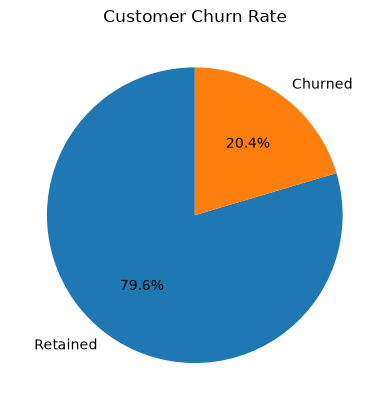

Churn rate: 20.4%


In [6]:
churn_status['ChurnStatus'].value_counts().sort_index().plot(
    kind='pie', labels=['Retained', 'Churned'], color=['#4C72B0', '#DD8452'], title='Customer Churn Rate', autopct='%1.1f%%', startangle=90)
plt.show()

print(f"Churn rate: {churn_status['ChurnStatus'].mean():.1%}")


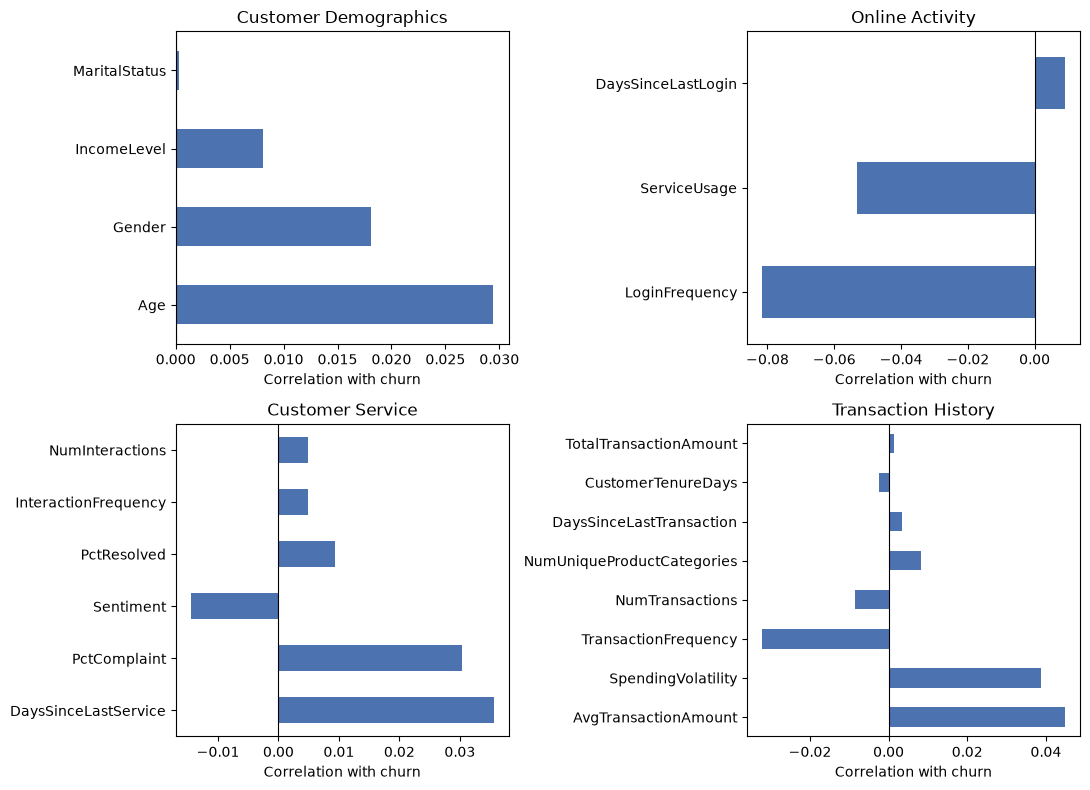

Top 5 features most correlated with churn:
LoginFrequency: -0.08
ServiceUsage: -0.05
AvgTransactionAmount: 0.04
SpendingVolatility: 0.04
DaysSinceLastService: 0.04


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (title, corr) in zip(axes.flat, [
    ("Customer Demographics", demo_corr),
    ("Online Activity", online_corr),
    ("Customer Service", service_corr),
    ("Transaction History", txn_corr),
]):
    corr.plot(kind='barh', ax=ax, color='#4C72B0')
    ax.set_title(title)
    ax.set_xlabel('Correlation with churn')
    ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 5 features most correlated with churn:")
feature_churns = {}
for corr in [demo_corr, online_corr, service_corr, txn_corr]:
    for feature, value in corr.items():
        feature_churns[feature] = value

top_features = sorted(feature_churns.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
for feature in top_features:
    print(f"{feature[0]}: {feature[1]:.2f}")

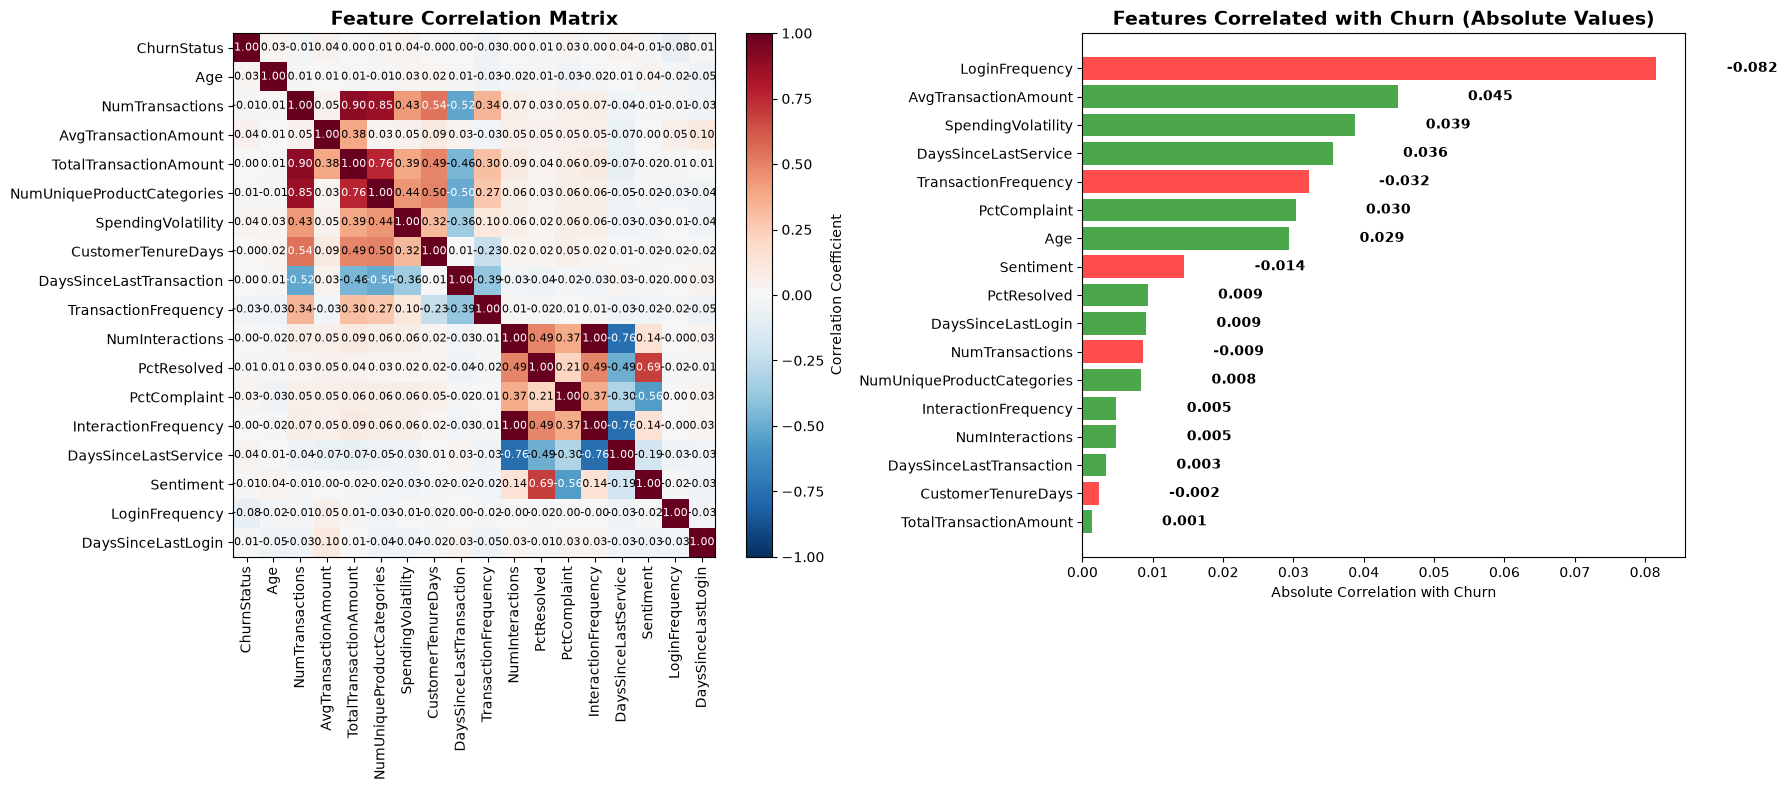


 Top correlation with churn:
  • LoginFrequency: -0.082
  • AvgTransactionAmount: 0.045
  • SpendingVolatility: 0.039
  • DaysSinceLastService: 0.036
  • TransactionFrequency: -0.032
  • PctComplaint: 0.030
  • Age: 0.029
  • Sentiment: -0.014
  • PctResolved: 0.009
  • DaysSinceLastLogin: 0.009


In [8]:
def correlation_analysis():
    """Analyse correlations between features and churn"""
        
    # Select numeric columns for correlation
    corr_matrix = combined_df.drop(columns='CustomerID').corr(numeric_only=True)
        
    # Create correlation heatmap
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
        
    # Full correlation matrix
    im1 = ax1.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax1.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(len(corr_matrix.columns))); ax1.set_xticklabels(corr_matrix.columns, rotation=90)
    ax1.set_yticks(range(len(corr_matrix.columns))); ax1.set_yticklabels(corr_matrix.columns)
        
    # Add correlation values
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            ax1.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
        
    plt.colorbar(im1, ax=ax1, label='Correlation Coefficient')
        
    # Churn correlation focus
    churn_corr = corr_matrix['ChurnStatus'].abs().sort_values(ascending=True)
    churn_corr = churn_corr[churn_corr.index != 'ChurnStatus']
        
    colors = ['red' if x < 0 else 'green' for x in corr_matrix['ChurnStatus'][churn_corr.index]]
    bars = ax2.barh(range(len(churn_corr)), churn_corr.values, color=colors, alpha=0.7)
    ax2.set_title('Features Correlated with Churn (Absolute Values)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Absolute Correlation with Churn')
    ax2.set_yticks(range(len(churn_corr)))
    ax2.set_yticklabels(churn_corr.index)
        
    # Add correlation values on bars
    for i, (feature, corr_val) in enumerate(zip(churn_corr.index, churn_corr.values)):
        actual_corr = corr_matrix['ChurnStatus'][feature]
        ax2.text(corr_val + 0.01, i, f'{actual_corr:.3f}', va='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()
        
    # Print top correlations with churn
    print("\n Top correlation with churn:")
    churn_corr_signed = corr_matrix['ChurnStatus'].drop('ChurnStatus').sort_values(key=abs, ascending=False)
        
    for feature, correlation in churn_corr_signed.head(10).items():
        print(f"  • {feature}: {correlation:.3f}")
        
    return corr_matrix
    
correlation_matrix = correlation_analysis()


# 4. In-Depth Analysis of Individual Datasets

* Analyse each of the 4 source datasets on its own terms, using the corresponding features already sitting in `combined_df`
* For each feature: its distribution, and the churn rate within each group/bin
* One or two exploratory plots per dataset combining multiple features

In [9]:
CHURN_COLOUR = '#B22222'  # used everywhere churn itself is being highlighted


def plot_continuous_vs_churn(df, col, target='ChurnStatus', bins=25, cmap='viridis',
                              diverging=False, log=False, figsize=(9, 4.5)):
    """Full-range histogram of `col`, bars coloured by their own value on `cmap`,
    with the churn rate per bin overlaid as a line on a second axis."""
    data = df[col].dropna()
    if log:
        edges = np.logspace(np.log10(max(data.min(), 1e-6)), np.log10(data.max()), bins + 1)
    else:
        edges = np.linspace(data.min(), data.max(), bins + 1)
    counts, _ = np.histogram(data, bins=edges)
    centers = (edges[:-1] + edges[1:]) / 2
    widths = np.diff(edges)

    norm = TwoSlopeNorm(vcenter=0, vmin=data.min(), vmax=data.max()) if diverging else Normalize(data.min(), data.max())
    colours = plt.get_cmap(cmap)(norm(centers))

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.bar(centers, counts, width=widths * 0.9, color=colours, edgecolor='white', linewidth=0.4)
    ax1.set_ylabel('Customers'); ax1.set_xlabel(col)
    if log:
        ax1.set_xscale('log')

    bin_idx = np.clip(np.digitize(data, edges[1:-1]), 0, len(centers) - 1)
    churn_rate = df.loc[data.index].groupby(bin_idx)[target].mean()

    ax2 = ax1.twinx()
    ax2.plot(centers[churn_rate.index], churn_rate.values, color=CHURN_COLOUR,
              marker='o', markersize=4, linewidth=2, label='Churn rate')
    ax2.axhline(df[target].mean(), color=CHURN_COLOUR, linestyle=':', linewidth=1, alpha=0.6)
    ax2.set_ylabel('Churn rate', color=CHURN_COLOUR)
    ax2.tick_params(axis='y', colors=CHURN_COLOUR)

    ax1.set_title(f'{col}: distribution and churn rate')
    fig.tight_layout()
    plt.show()


def plot_mosaic_churn(df, col, target='ChurnStatus', order=None, cmap='Set2', colours=None, figsize=(7, 5)):
    """Variable-width stacked bars: bar width = category's share of customers,
    split height = churn rate within that category. Churned segment is always red."""
    counts = df[col].value_counts()
    if order is not None:
        counts = counts.reindex(order)
    shares = counts / counts.sum()
    churn_rates = df.groupby(col, observed=True)[target].mean().reindex(counts.index)
    if not colours:
        colours = plt.get_cmap(cmap)(np.linspace(0.15, 0.85, len(counts)))

    fig, ax = plt.subplots(figsize=figsize)
    x = 0
    for i, cat in enumerate(counts.index):
        w = shares[cat]
        churned_h = churn_rates[cat]
        ax.bar(x + w / 2, 1 - churned_h, width=w, color=colours[i], alpha=0.9, edgecolor='white')
        ax.bar(x + w / 2, churned_h, width=w, bottom=1 - churned_h, color=CHURN_COLOUR, alpha=0.9, edgecolor='white')
        ax.text(x + w / 2, -0.05, f'{cat}\n(n={counts[cat]})', ha='center', va='top', fontsize=9)
        ax.text(x + w / 2, 1.02, f'{churned_h:.0%}', ha='center', va='bottom', fontsize=9, color=CHURN_COLOUR)
        x += w

    ax.set_xlim(0, 1); ax.set_ylim(0, 1.1)
    ax.set_xticks([]); ax.set_ylabel('Share retained (colour) vs churned (red)')
    ax.set_title(f'{col}: distribution (width) and churn rate (split)')
    plt.tight_layout()
    plt.show()


def plot_relationship(df, x, y, target='ChurnStatus', figsize=(6, 4.5)):
    """Scatter x vs y, coloured by churn, to explore how two features interact."""
    fig, ax = plt.subplots(figsize=figsize)
    for status, colour, label in [(0, '#4C72B0', 'Retained'), (1, CHURN_COLOUR, 'Churned')]:
        subset = df[df[target] == status]
        ax.scatter(subset[x], subset[y], alpha=0.5, s=15, color=colour, label=label)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.legend()
    plt.title(f'{y} vs {x} by churn')
    plt.tight_layout()
    plt.show()


def plot_heatmap_churn(df, x, y, target='ChurnStatus', figsize=(6, 4)):
    """Churn rate across the combination of two categorical/grouped features."""
    pivot = df.pivot_table(index=y, columns=x, values=target, aggfunc='mean')
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot, cmap='coolwarm')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    plt.colorbar(im, label='Churn rate')
    plt.title(f'Churn rate by {y} and {x}')
    plt.tight_layout()
    plt.show()


def plot_bubble_churn(df, x, y, target='ChurnStatus', cmap='coolwarm', figsize=(6.5, 5)):
    """For two low-cardinality features: one dot per combination, sized by how many
    customers sit there and coloured by churn rate - reveals density that a plain
    scatter hides when points stack on top of each other."""
    grp = df.groupby([x, y], observed=True)[target].agg(['size', 'mean']).reset_index()
    sizes = grp['size'] / grp['size'].max() * 900 + 40

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(grp[x], grp[y], s=sizes, c=grp['mean'], cmap=cmap, edgecolor='white', alpha=0.9)
    for _, row in grp.iterrows():
        ax.annotate(int(row['size']), (row[x], row[y]), ha='center', va='center', fontsize=8)
    plt.colorbar(sc, label='Churn rate')
    ax.set_xlabel(x); ax.set_ylabel(y)
    plt.title(f'{y} vs {x}: bubble size = customers, colour = churn rate')
    plt.tight_layout()
    plt.show()


## 4.1 Customer Demographics

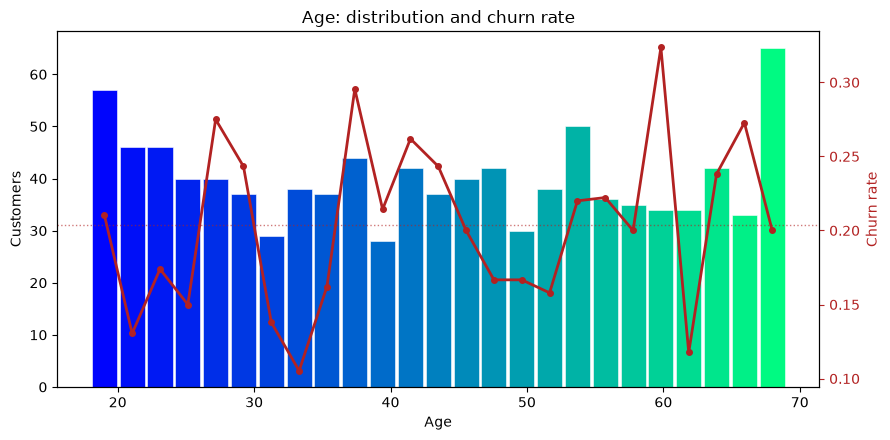

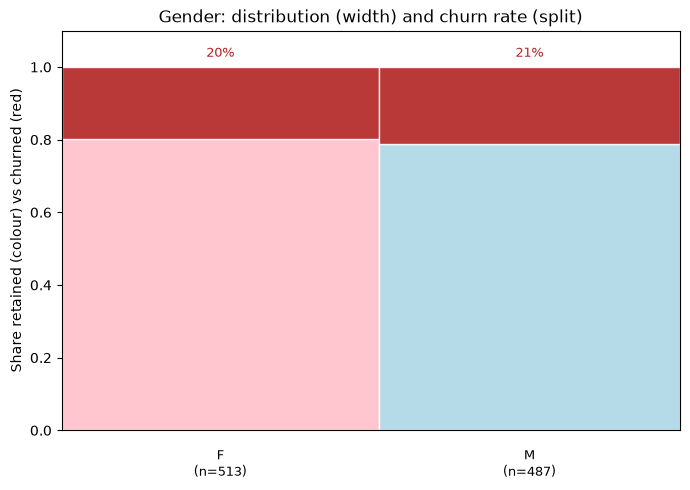

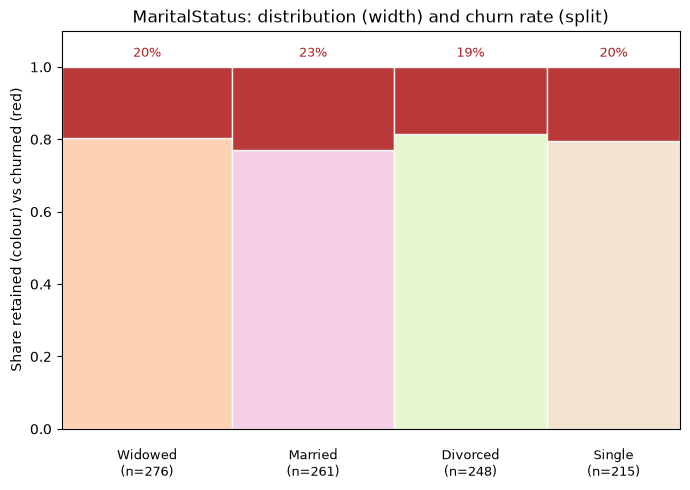

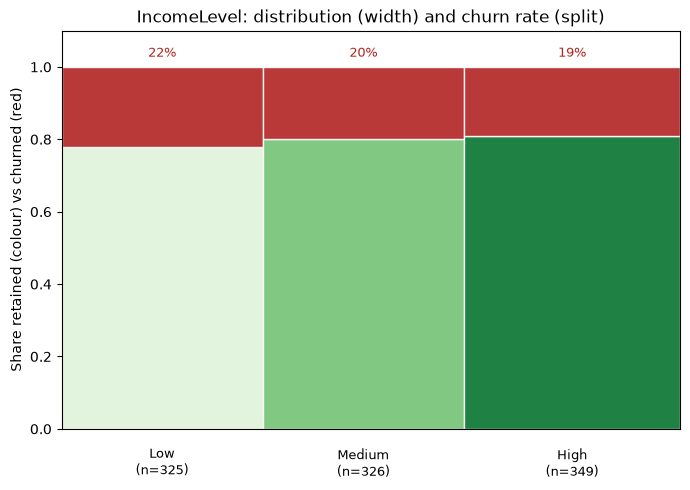

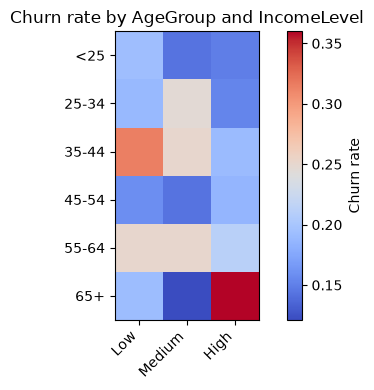

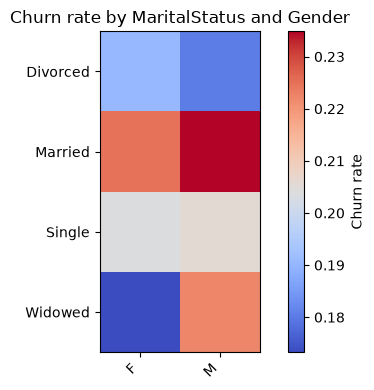

In [10]:
plot_continuous_vs_churn(combined_df, 'Age', bins=25, cmap='winter')

plot_mosaic_churn(combined_df, 'Gender', colours=['pink', 'lightblue'])

plot_mosaic_churn(combined_df, 'MaritalStatus', cmap='Pastel2')

combined_df['IncomeLevel'] = pd.Categorical(combined_df['IncomeLevel'], categories=['Low', 'Medium', 'High'], ordered=True)
plot_mosaic_churn(combined_df, 'IncomeLevel', order=['Low', 'Medium', 'High'], cmap='Greens')

# exploratory: does income level's effect on churn depend on age group? does gender interact with marital status?
combined_df['AgeGroup'] = pd.cut(combined_df['Age'], bins=[0, 25, 35, 45, 55, 65, 120],
                                  labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'])
plot_heatmap_churn(combined_df, x='IncomeLevel', y='AgeGroup')
plot_heatmap_churn(combined_df, x='Gender', y='MaritalStatus')


## 4.2 Transaction History

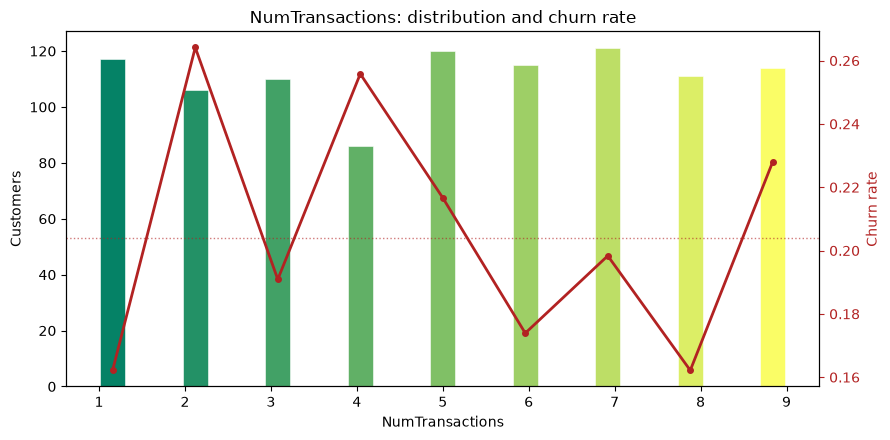

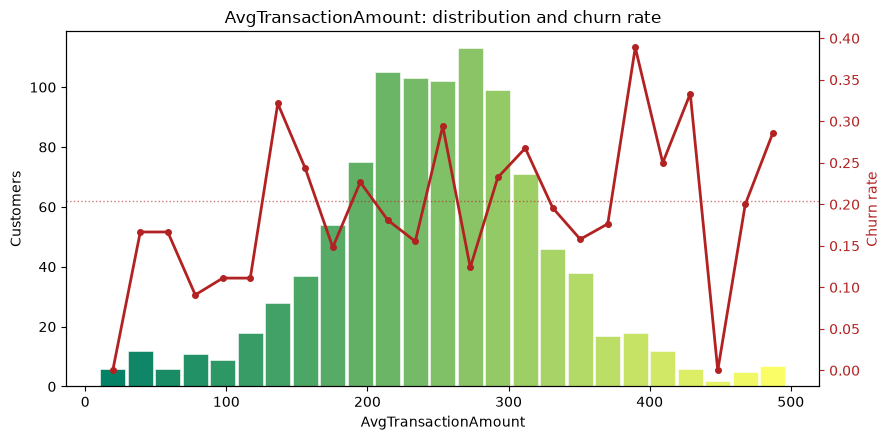

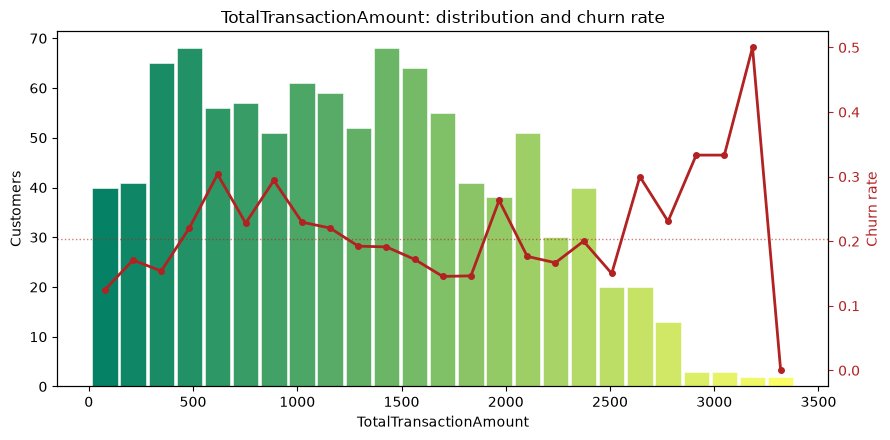

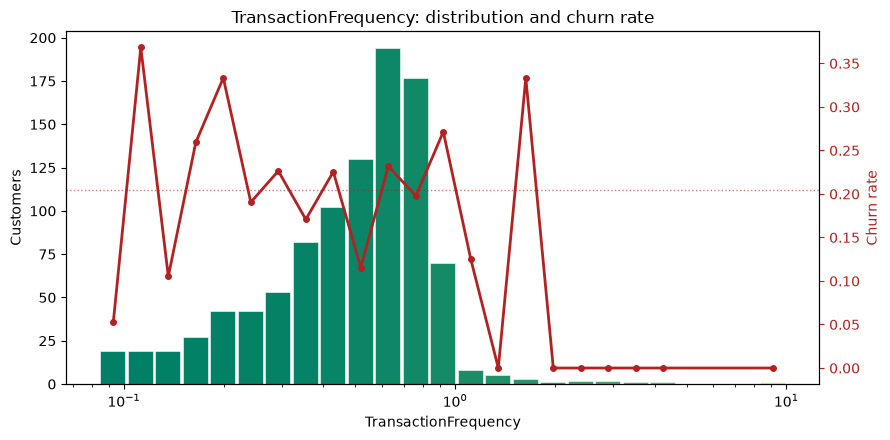

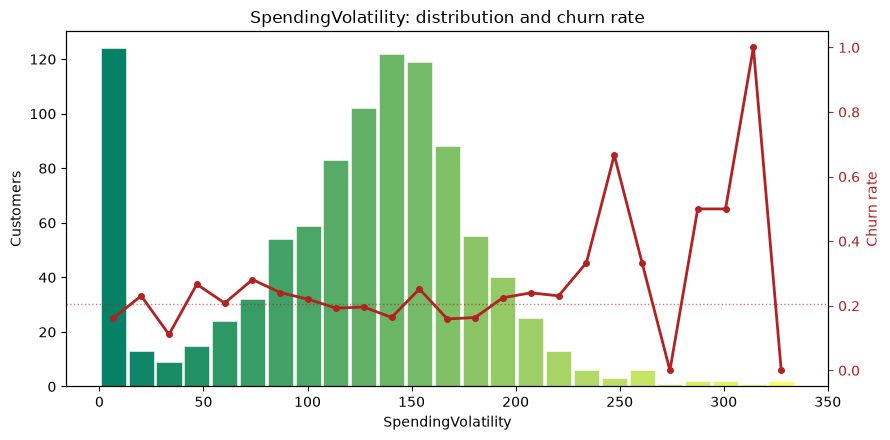

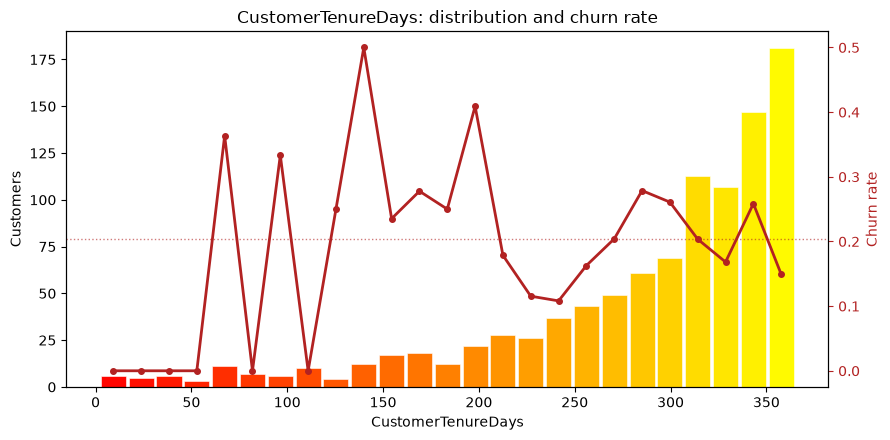

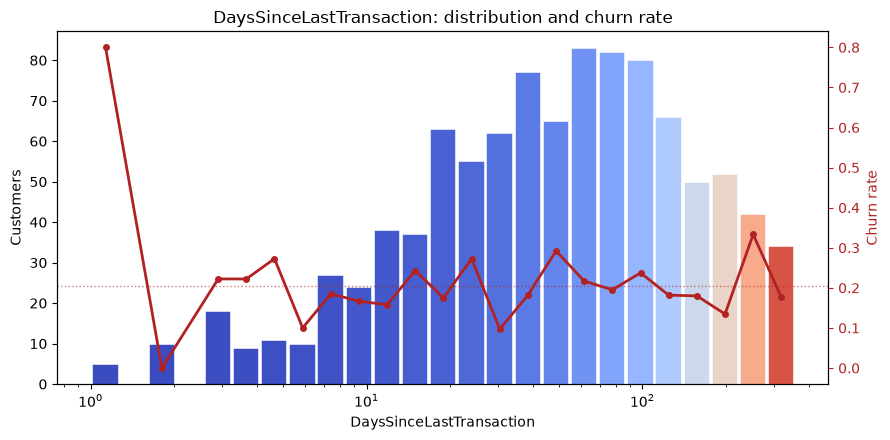

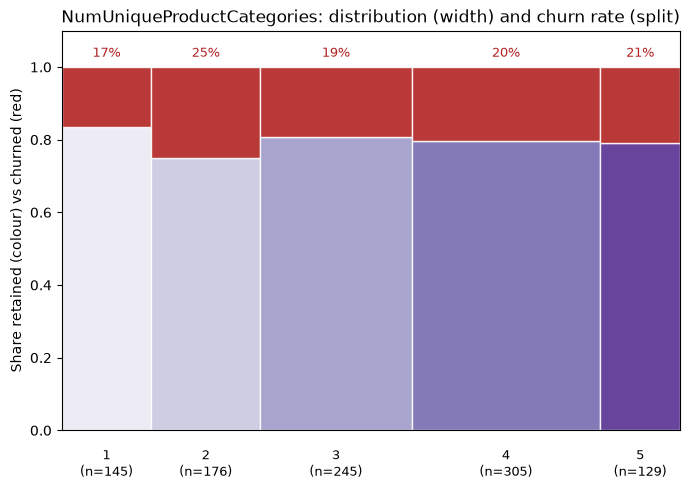

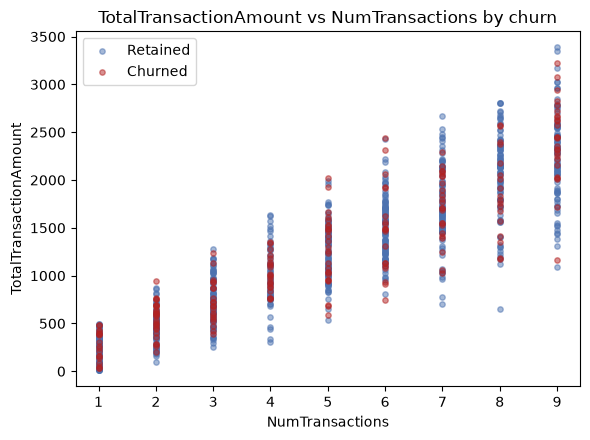

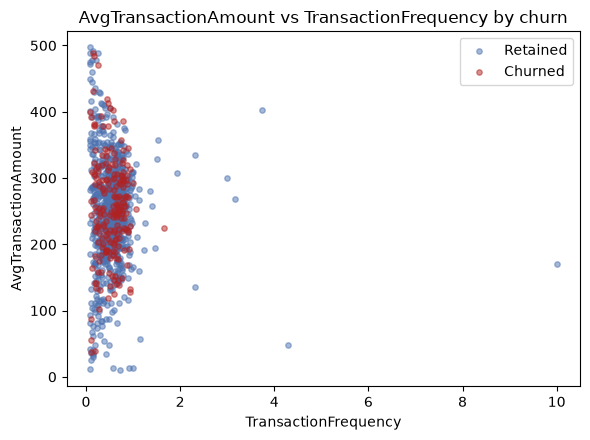

In [15]:
plot_continuous_vs_churn(combined_df, 'NumTransactions', cmap='summer')
plot_continuous_vs_churn(combined_df, 'AvgTransactionAmount', cmap='summer')
plot_continuous_vs_churn(combined_df, 'TotalTransactionAmount', cmap='summer')
plot_continuous_vs_churn(combined_df, 'TransactionFrequency', cmap='summer', log=True)
plot_continuous_vs_churn(combined_df, 'SpendingVolatility', cmap='summer')
plot_continuous_vs_churn(combined_df, 'CustomerTenureDays', cmap='autumn')
plot_continuous_vs_churn(combined_df, 'DaysSinceLastTransaction', cmap='coolwarm', log=True)
plot_mosaic_churn(combined_df, 'NumUniqueProductCategories',
                   order=sorted(combined_df['NumUniqueProductCategories'].unique()), cmap='Purples')

# exploratory: do high-frequency spenders also spend more per transaction? does that combination relate to churn?
plot_relationship(combined_df, 'NumTransactions', 'TotalTransactionAmount')
plot_relationship(combined_df, 'TransactionFrequency', 'AvgTransactionAmount')


## 4.3 Customer Service

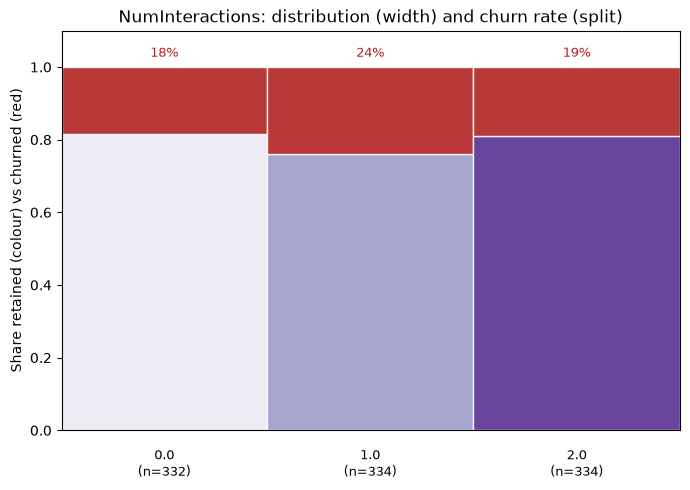

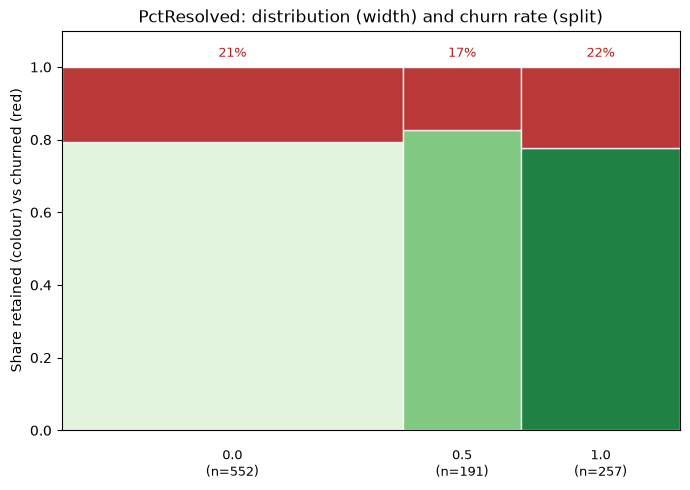

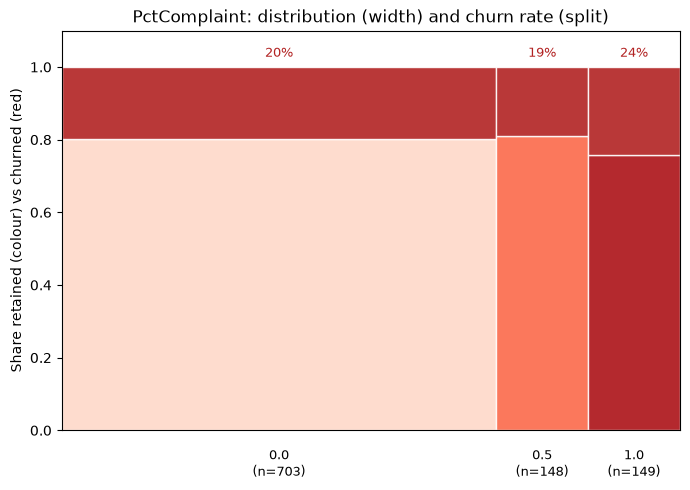

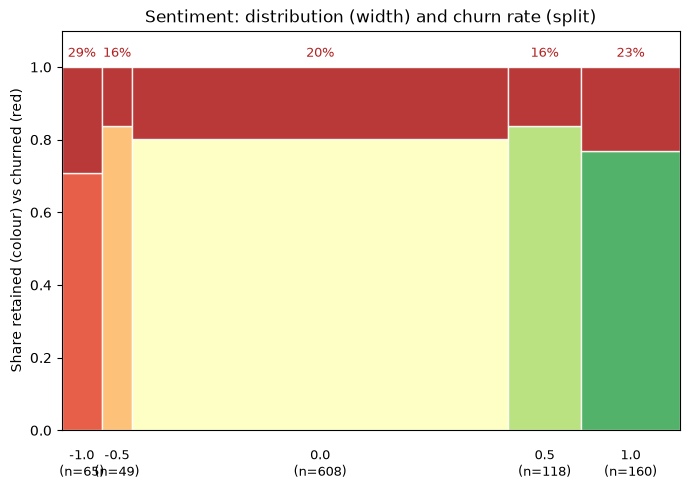

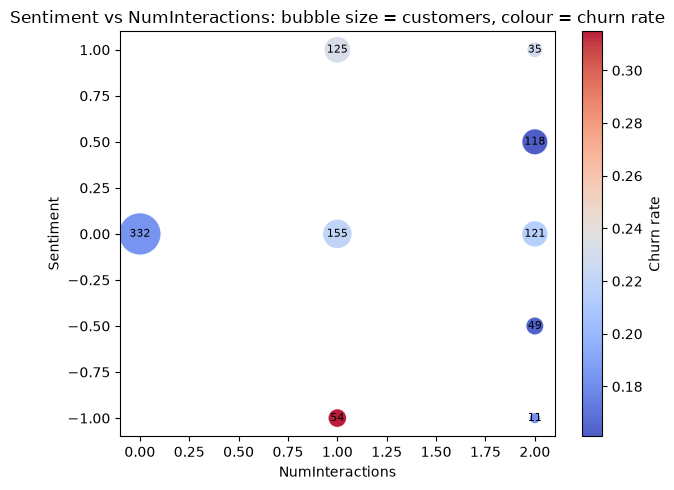

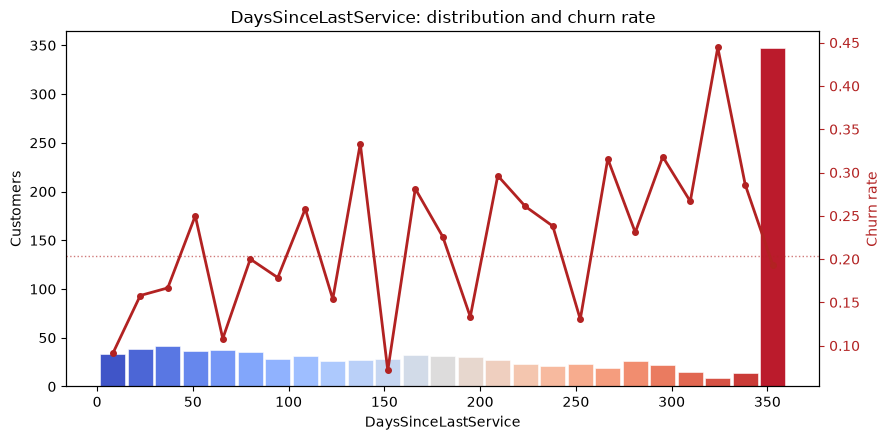

In [16]:
# these features only take a handful of distinct values
plot_mosaic_churn(combined_df, 'NumInteractions',
                   order=sorted(combined_df['NumInteractions'].unique()), cmap='Purples')
plot_mosaic_churn(combined_df, 'PctResolved',
                   order=sorted(combined_df['PctResolved'].unique()), cmap='Greens')
plot_mosaic_churn(combined_df, 'PctComplaint',
                   order=sorted(combined_df['PctComplaint'].unique()), cmap='Reds')
plot_mosaic_churn(combined_df, 'Sentiment',
                   order=sorted(combined_df['Sentiment'].unique()), cmap='RdYlGn')

# exploratory: does more contact only correlate with churn when sentiment is negative?
plot_bubble_churn(combined_df, 'NumInteractions', 'Sentiment')

plot_continuous_vs_churn(combined_df, 'DaysSinceLastService', cmap='coolwarm')


## 4.4 Online Activity

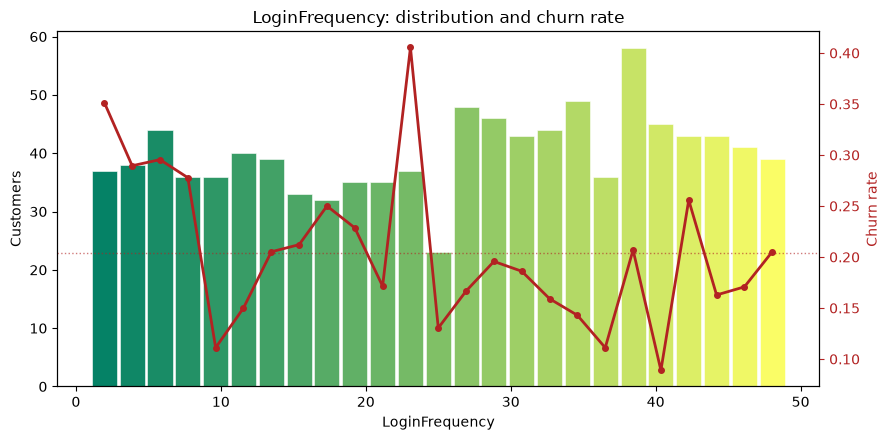

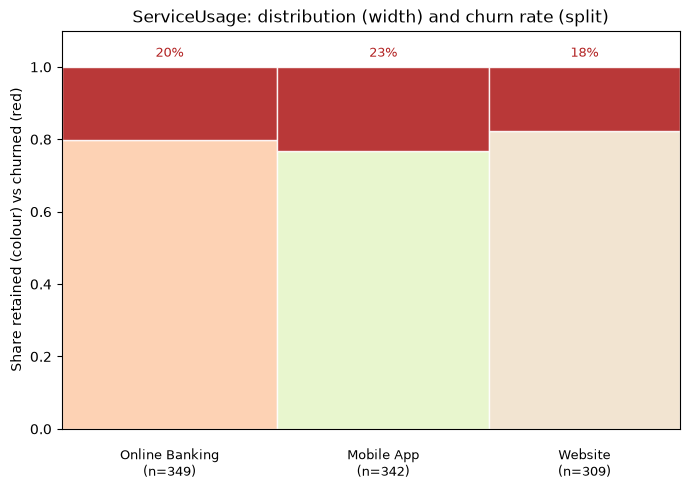

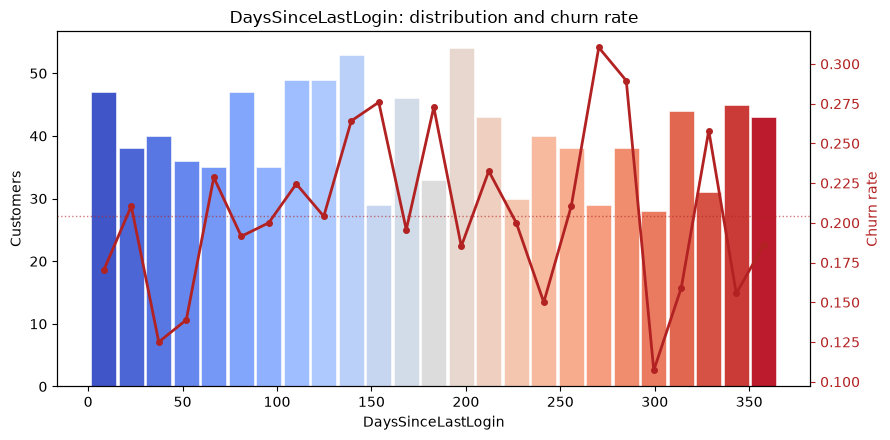

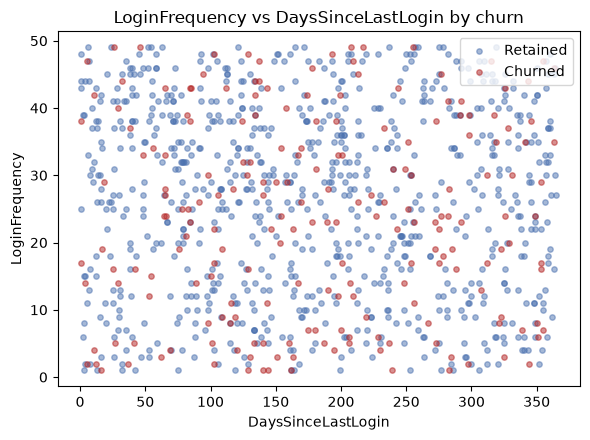

In [17]:
plot_continuous_vs_churn(combined_df, 'LoginFrequency', cmap='summer')
plot_mosaic_churn(combined_df, 'ServiceUsage', cmap='Pastel2')
plot_continuous_vs_churn(combined_df, 'DaysSinceLastLogin', cmap='coolwarm')

# exploratory: does infrequent, long-absent usage compound?
plot_relationship(combined_df, 'DaysSinceLastLogin', 'LoginFrequency')


# 5. Anomaly Detection & Key Insights

* Top predictive features across all four datasets
* For each dataset: churn rate by category (categorical features) and the highest-churn group (continuous features)
* Anomalies and red flags worth investigating before modelling
* Recommended actions based on the findings above

Top predictive features overall:

             Feature  Correlation             Dataset
      LoginFrequency    -0.081615     Online Activity
        ServiceUsage    -0.053155     Online Activity
AvgTransactionAmount     0.044811 Transaction History
  SpendingVolatility     0.038818 Transaction History
DaysSinceLastService     0.035587    Customer Service
TransactionFrequency    -0.032164 Transaction History
        PctComplaint     0.030305    Customer Service
                 Age     0.029407        Demographics
              Gender     0.018132        Demographics
           Sentiment    -0.014483    Customer Service


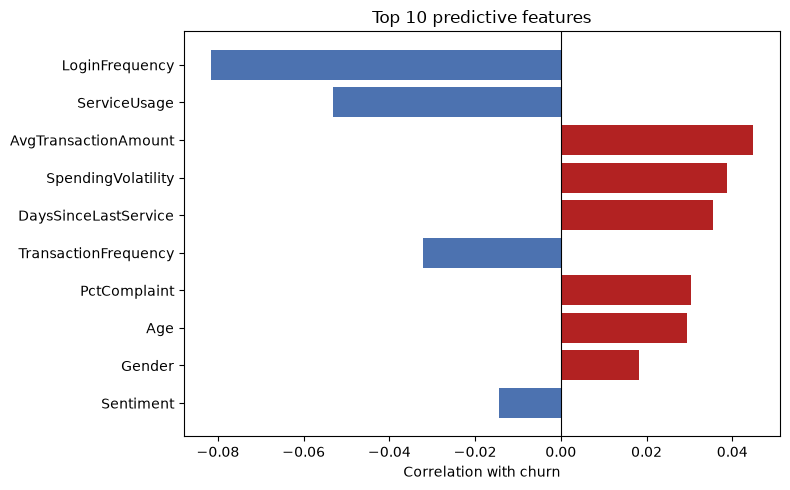

In [18]:
all_corr = pd.concat([
    demo_corr.rename('Correlation').to_frame().assign(Dataset='Demographics'),
    txn_corr.rename('Correlation').to_frame().assign(Dataset='Transaction History'),
    service_corr.rename('Correlation').to_frame().assign(Dataset='Customer Service'),
    online_corr.rename('Correlation').to_frame().assign(Dataset='Online Activity'),
]).reset_index().rename(columns={'index': 'Feature'})
all_corr['AbsCorrelation'] = all_corr['Correlation'].abs()
top_features = all_corr.sort_values('AbsCorrelation', ascending=False).drop(columns='AbsCorrelation')

print("Top predictive features overall:\n")
print(top_features.head(10).to_string(index=False))

top10 = top_features.head(10).iloc[::-1]
colours = ['#B22222' if v > 0 else '#4C72B0' for v in top10['Correlation']]
plt.figure(figsize=(8, 5))
plt.barh(top10['Feature'], top10['Correlation'], color=colours)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with churn')
plt.title('Top 10 predictive features')
plt.tight_layout()
plt.show()


In [19]:
def churn_by_category(df, col, target='ChurnStatus'):
    """Print the churn rate within each category of a categorical/discrete feature."""
    rates = df.groupby(col, observed=True)[target].mean().sort_values(ascending=False)
    print(f"{col}:")
    for cat, rate in rates.items():
        print(f"  {cat}: {rate:.1%} churn")
    print()



def highest_churn_group(df, col, target='ChurnStatus', q=4):
    """Bucket a continuous feature into quantiles and report which one churns most."""
    grouped = pd.qcut(df[col], q=q, duplicates='drop')
    rates = df.groupby(grouped, observed=True)[target].mean().sort_values(ascending=False)
    print(f"{col}: highest churn rate is {rates.iloc[0]:.1%} for range {rates.index[0]} "
          f"(overall rate: {df[target].mean():.1%})")
    print()



## 5.1 Customer Demographics

In [20]:
for col in ['Gender', 'MaritalStatus', 'IncomeLevel']:
    churn_by_category(combined_df, col)

highest_churn_group(combined_df, 'Age')


Gender:
  M: 21.1% churn
  F: 19.7% churn

MaritalStatus:
  Married: 23.0% churn
  Single: 20.5% churn
  Widowed: 19.6% churn
  Divorced: 18.5% churn

IncomeLevel:
  Low: 22.2% churn
  Medium: 19.9% churn
  High: 19.2% churn

Age: highest churn rate is 22.2% for range (56.0, 69.0] (overall rate: 20.4%)



## 5.2 Transaction History

In [21]:
churn_by_category(combined_df, 'NumUniqueProductCategories')

for col in ['NumTransactions', 'AvgTransactionAmount', 'TotalTransactionAmount', 'TransactionFrequency',
            'SpendingVolatility', 'CustomerTenureDays', 'DaysSinceLastTransaction']:
    highest_churn_group(combined_df, col)


NumUniqueProductCategories:
  2: 25.0% churn
  5: 20.9% churn
  4: 20.3% churn
  3: 19.2% churn
  1: 16.6% churn

NumTransactions: highest churn rate is 23.3% for range (3.0, 5.0] (overall rate: 20.4%)

AvgTransactionAmount: highest churn rate is 24.8% for range (295.024, 496.99] (overall rate: 20.4%)

TotalTransactionAmount: highest churn rate is 25.2% for range (626.685, 1232.88] (overall rate: 20.4%)

TransactionFrequency: highest churn rate is 22.0% for range (0.083, 0.34] (overall rate: 20.4%)

SpendingVolatility: highest churn rate is 20.8% for range (159.626, 334.306] (overall rate: 20.4%)

CustomerTenureDays: highest churn rate is 23.8% for range (256.0, 314.0] (overall rate: 20.4%)

DaysSinceLastTransaction: highest churn rate is 21.1% for range (53.0, 107.0] (overall rate: 20.4%)



## 5.3 Customer Service

In [22]:
# all low-cardinality, so every feature is treated as categorical
for col in ['NumInteractions', 'PctResolved', 'PctComplaint', 'Sentiment']:
    churn_by_category(combined_df, col)

highest_churn_group(combined_df, 'DaysSinceLastService')


NumInteractions:
  1.0: 24.0% churn
  2.0: 18.9% churn
  0.0: 18.4% churn

PctResolved:
  1.0: 22.2% churn
  0.0: 20.7% churn
  0.5: 17.3% churn

PctComplaint:
  1.0: 24.2% churn
  0.0: 19.9% churn
  0.5: 18.9% churn

Sentiment:
  -1.0: 29.2% churn
  1.0: 23.1% churn
  0.0: 19.9% churn
  -0.5: 16.3% churn
  0.5: 16.1% churn

DaysSinceLastService: highest churn rate is 21.8% for range (226.0, 360.0] (overall rate: 20.4%)



## 5.4 Online Activity

In [23]:
churn_by_category(combined_df, 'ServiceUsage')

for col in ['LoginFrequency', 'DaysSinceLastLogin']:
    highest_churn_group(combined_df, col)


ServiceUsage:
  Mobile App: 23.1% churn
  Online Banking: 20.1% churn
  Website: 17.8% churn

LoginFrequency: highest churn rate is 23.6% for range (0.999, 13.75] (overall rate: 20.4%)

DaysSinceLastLogin: highest churn rate is 22.4% for range (91.75, 174.5] (overall rate: 20.4%)



## 5.5 Anomalies & Red Flags

In [24]:
# outliers via IQR on continuous features - and whether outliers themselves churn differently
continuous_cols = ['Age', 'NumTransactions', 'AvgTransactionAmount', 'TotalTransactionAmount',
                    'TransactionFrequency', 'SpendingVolatility', 'CustomerTenureDays',
                    'DaysSinceLastTransaction', 'LoginFrequency', 'DaysSinceLastLogin', 'DaysSinceLastService']

for col in continuous_cols:
    q1, q3 = combined_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = combined_df[(combined_df[col] < lower) | (combined_df[col] > upper)]
    if len(outliers):
        print(f"{col}: {len(outliers)} outliers ({len(outliers) / len(combined_df):.1%}) outside "
              f"[{lower:.1f}, {upper:.1f}] - churn rate among them: {outliers['ChurnStatus'].mean():.1%} "
              f"vs {combined_df['ChurnStatus'].mean():.1%} overall")

print()

# 'ghost' customers: no transactions and no service interactions at all
ghosts = combined_df[(combined_df['NumTransactions'] == 0) & (combined_df['NumInteractions'] == 0)]
if len(ghosts):
    print(f"'Ghost' customers (zero transactions, zero service interactions): {len(ghosts)} "
          f"({len(ghosts) / len(combined_df):.1%}) - churn rate: {ghosts['ChurnStatus'].mean():.1%}")
else:
    print("No customers with zero transactions and zero service interactions.")

# customers whose every service contact was an unresolved complaint - a clear risk combination
high_risk = combined_df[(combined_df['PctComplaint'] == combined_df['PctComplaint'].max()) & (combined_df['PctResolved'] == 0)]
if len(high_risk):
    print(f"Customers with 100% unresolved complaints: {len(high_risk)} - churn rate: {high_risk['ChurnStatus'].mean():.1%}")
else:
    print("No customers with 100% unresolved complaints.")

# customers with at least one unresolved interaction and one complaint
some_risk = combined_df[(combined_df['PctComplaint'] > 0) & (combined_df['PctResolved'] < 1)]
if len(some_risk):
    print(f"Customers with at least one unresolved interaction and one complaint: {len(some_risk)} "
          f"({len(some_risk) / len(combined_df):.1%}) - churn rate: {some_risk['ChurnStatus'].mean():.1%}")
    
# customers with some unresolved interation
some_unresolved = combined_df[(combined_df['NumInteractions'] > 0) & (combined_df['PctResolved'] < 1)]
if len(some_unresolved):
    print(f"Customers with at least one unresolved interaction: {len(some_unresolved)} "
          f"({len(some_unresolved) / len(combined_df):.1%}) - churn rate: {some_unresolved['ChurnStatus'].mean():.1%}")

AvgTransactionAmount: 38 outliers (3.8%) outside [66.8, 432.0] - churn rate among them: 15.8% vs 20.4% overall
TransactionFrequency: 15 outliers (1.5%) outside [-0.2, 1.2] - churn rate among them: 6.7% vs 20.4% overall
SpendingVolatility: 8 outliers (0.8%) outside [-15.4, 264.6] - churn rate among them: 37.5% vs 20.4% overall
CustomerTenureDays: 56 outliers (5.6%) outside [124.0, 476.0] - churn rate among them: 10.7% vs 20.4% overall
DaysSinceLastTransaction: 66 outliers (6.6%) outside [-108.0, 236.0] - churn rate among them: 24.2% vs 20.4% overall

No customers with zero transactions and zero service interactions.
Customers with 100% unresolved complaints: 65 - churn rate: 29.2%
Customers with at least one unresolved interaction and one complaint: 200 (20.0%) - churn rate: 22.0%
Customers with at least one unresolved interaction: 411 (41.1%) - churn rate: 20.9%


## 5.6 Recommended Actions

In [25]:
FEATURE_ACTIONS = {
    'Sentiment': 'Prioritise proactive outreach to customers with negative service sentiment before they churn.',
    'PctComplaint': 'Investigate root causes of complaints and fast-track their resolution - unresolved complaints are a strong churn driver.',
    'PctResolved': 'Improve first-contact resolution rates; customers with low resolution rates churn more.',
    'DaysSinceLastLogin': "Re-engage customers who haven't logged in recently with targeted reminders or offers.",
    'LoginFrequency': 'Encourage regular platform engagement through habit-forming features or notifications.',
    'TotalTransactionAmount': 'Offer loyalty incentives to high-value customers to protect revenue-critical accounts.',
    'TransactionFrequency': 'Target infrequent transactors with re-engagement campaigns.',
    'NumTransactions': "Monitor customers whose transaction volume is dropping as an early churn signal.",
    'AvgTransactionAmount': 'Segment retention campaigns by typical spend size.',
    'IncomeLevel': 'Tailor retention offers by income segment.',
    'Age': 'Design age-appropriate retention messaging and channels.',
    'AgeGroup': 'Design age-appropriate retention messaging and channels.',
    'Gender': 'Ensure retention campaigns are equally effective across gender groups.',
    'MaritalStatus': 'Consider household-oriented offers for at-risk marital status segments.',
    'NumInteractions': 'Track customers with unusually high contact volume as a churn early-warning sign.',
    'NumUniqueProductCategories': 'Encourage cross-category purchases to increase engagement and stickiness.',
    'ServiceUsage': 'Align channel-specific retention strategies (app vs website) with usage patterns.',
    'SpendingVolatility': 'Investigate customers with highly inconsistent spending - volatility itself can signal instability before churn.',
    'CustomerTenureDays': 'Build a tenure-specific onboarding/engagement programme - new and long-standing customers likely churn for different reasons.',
    'DaysSinceLastTransaction': 'Flag customers with a long gap since their last purchase for reactivation campaigns.',
    'DaysSinceLastService': 'Proactively check in with customers who have gone quiet on support, not just ones actively complaining.',
}

print("Recommended actions based on the top predictive features:\n")
for _, row in top_features.head(5).iterrows():
    action = FEATURE_ACTIONS.get(row['Feature'], 'Investigate this feature further as part of a targeted retention strategy.')
    print(f"- {row['Feature']} (corr={row['Correlation']:.2f}, {row['Dataset']}): {action}")


Recommended actions based on the top predictive features:

- LoginFrequency (corr=-0.08, Online Activity): Encourage regular platform engagement through habit-forming features or notifications.
- ServiceUsage (corr=-0.05, Online Activity): Align channel-specific retention strategies (app vs website) with usage patterns.
- AvgTransactionAmount (corr=0.04, Transaction History): Segment retention campaigns by typical spend size.
- SpendingVolatility (corr=0.04, Transaction History): Investigate customers with highly inconsistent spending - volatility itself can signal instability before churn.
- DaysSinceLastService (corr=0.04, Customer Service): Proactively check in with customers who have gone quiet on support, not just ones actively complaining.


# 6. Data Cleaning for Machine Learning

* One-hot encode the remaining categorical features (Gender, MaritalStatus, ServiceUsage)
* Convert IncomeLevel to an ordinal numeric scale (Low/Medium/High -> 1/2/3)
* Drop the AgeGroup column (superseded by raw Age) and CustomerID (not predictive)
* Confirm no missing values remain before modelling


 Outlier Dectection using IQR method:
  Age:
    • Outliers: 0 (0.0%)
    • Valid range: -9.00 to 95.00
  NumTransactions:
    • Outliers: 0 (0.0%)
    • Valid range: -3.00 to 13.00
  AvgTransactionAmount:
    • Outliers: 38 (3.8%)
    • Valid range: 66.80 to 431.96
    • Churn rate - Outliers: 15.8%, Normal: 20.6%
  TotalTransactionAmount:
    • Outliers: 0 (0.0%)
    • Valid range: -1121.14 to 3539.73
  NumUniqueProductCategories:
    • Outliers: 0 (0.0%)
    • Valid range: -1.00 to 7.00
  SpendingVolatility:
    • Outliers: 8 (0.8%)
    • Valid range: -15.36 to 264.62
    • Churn rate - Outliers: 37.5%, Normal: 20.3%
  CustomerTenureDays:
    • Outliers: 56 (5.6%)
    • Valid range: 124.00 to 476.00
    • Churn rate - Outliers: 10.7%, Normal: 21.0%
  DaysSinceLastTransaction:
    • Outliers: 66 (6.6%)
    • Valid range: -108.00 to 236.00
    • Churn rate - Outliers: 24.2%, Normal: 20.1%
  TransactionFrequency:
    • Outliers: 15 (1.5%)
    • Valid range: -0.21 to 1.25
    • Churn r

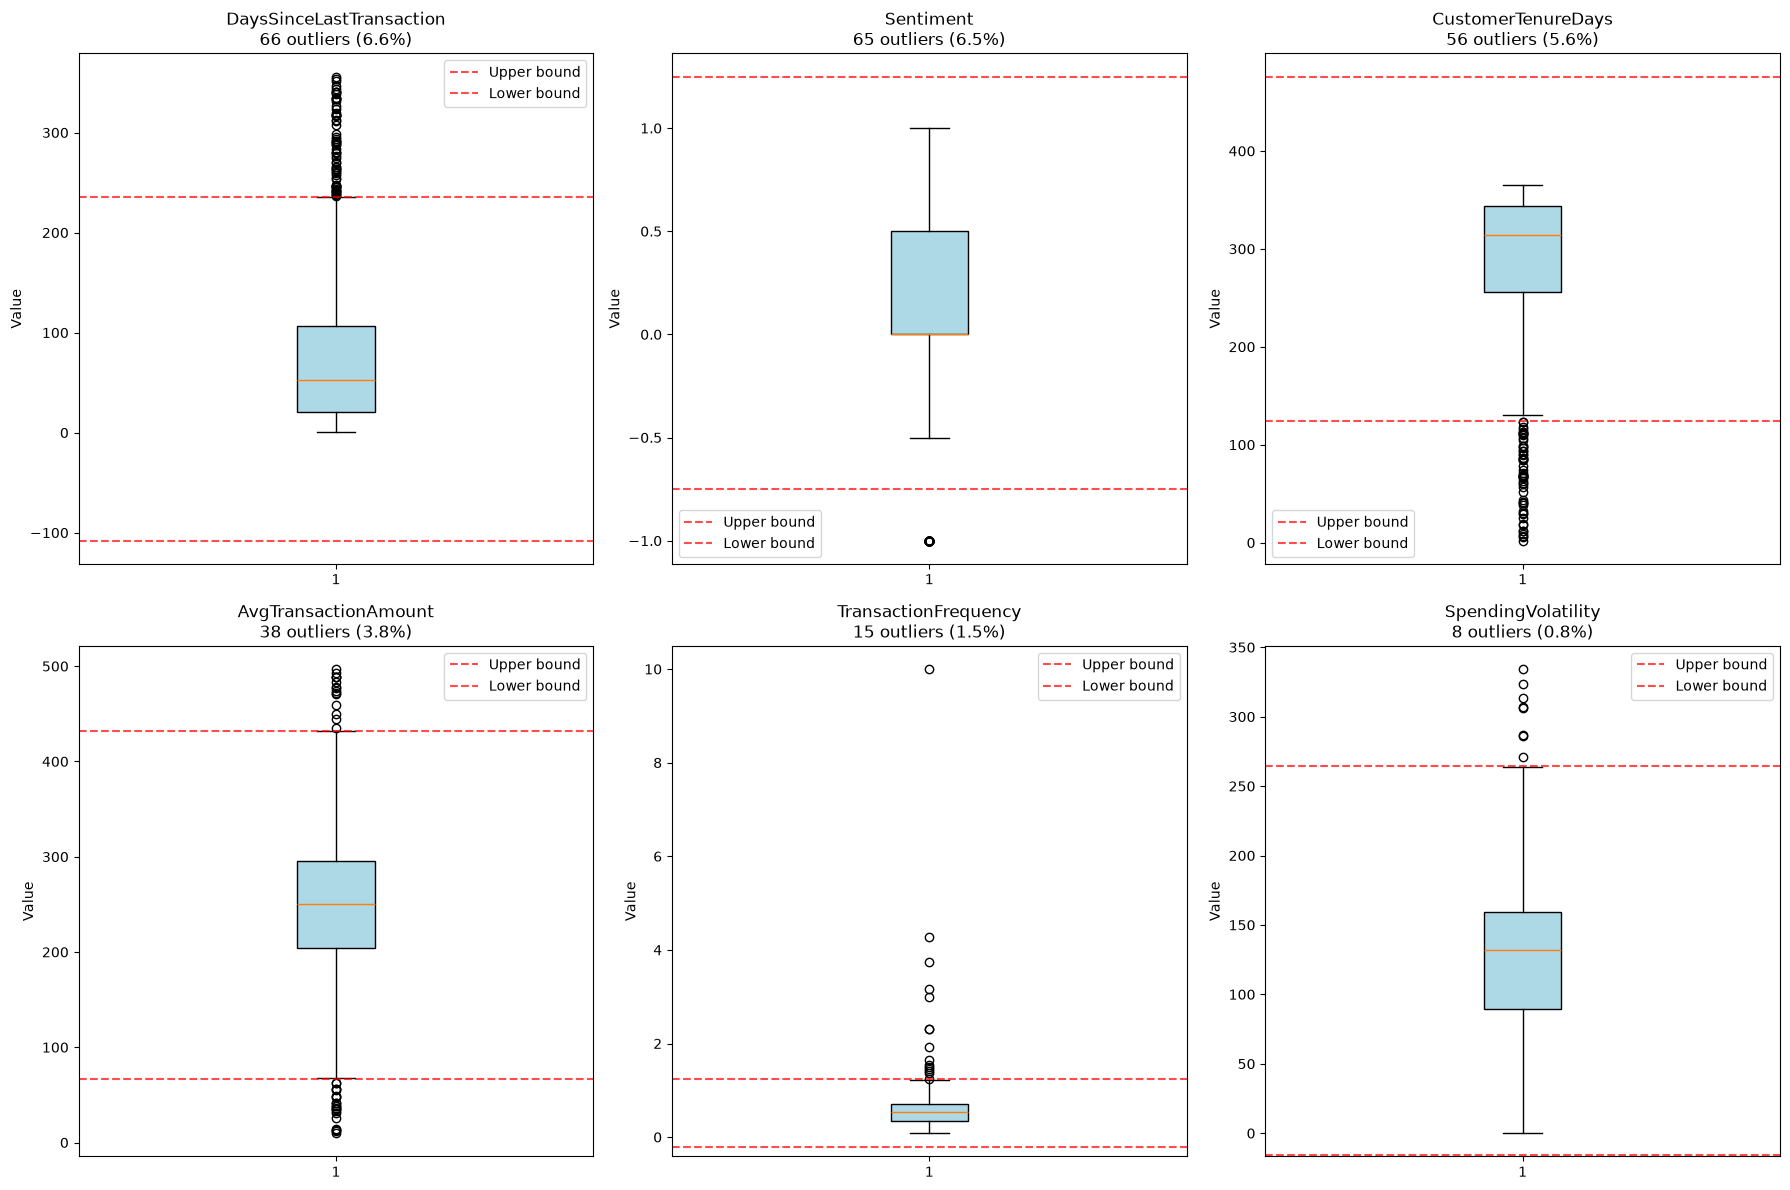

Outlier Treatment Summary:
  - AvgTransactionAmount: kept outliers (potential high-value customers)
  - SpendingVolatility: kept outliers (potential high-value customers)
  - CustomerTenureDays: kept outliers (legitimate high-engagement customers)
  - DaysSinceLastTransaction: kept outliers (meaningful inactivity signal)
  - TransactionFrequency: kept outliers (legitimate high-engagement customers)
  - Sentiment: kept outliers (legitimate high-engagement customers)


In [26]:
from scipy.stats import zscore

def detect_outliers(df, method='iqr'):
    """Detect outliers using multiple methods"""
        
    print(f"\n Outlier Dectection using {method.upper()} method:")
        
    # Select numerical columns for outlier detection
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    exclude_cols = ['CustomerID', 'ChurnStatus']  # Don't treat these as having outliers
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
        
    outlier_summary = {}
        
    for col in numeric_cols:
        if method == 'iqr':
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            
        elif method == 'zscore':
            z_scores = np.abs(zscore(df[col]))
            outliers = df[z_scores > 3]
            lower_bound = df[col].mean() - 3 * df[col].std()
            upper_bound = df[col].mean() + 3 * df[col].std()
            
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100
            
        outlier_summary[col] = {
            'count': outlier_count,
            'percentage': outlier_percentage,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_indices': outliers.index.tolist()
        }
            
        print(f"  {col}:")
        print(f"    • Outliers: {outlier_count} ({outlier_percentage:.1f}%)")
        print(f"    • Valid range: {lower_bound:.2f} to {upper_bound:.2f}")
            
        if outlier_count > 0:
            # Analyse churn rate in outliers vs normal
            outlier_churn_rate = outliers['ChurnStatus'].mean() if 'ChurnStatus' in df.columns else 0
            normal_data = df[~df.index.isin(outliers.index)]
            normal_churn_rate = normal_data['ChurnStatus'].mean() if 'ChurnStatus' in df.columns else 0
            print(f"    • Churn rate - Outliers: {outlier_churn_rate:.1%}, Normal: {normal_churn_rate:.1%}")
        
    return outlier_summary
    
def visualize_outliers(df, outlier_summary):
    """Visualise outliers for key features"""
    
        
    # Select top features with most outliers
    sorted_features = sorted(outlier_summary.items(), key=lambda x: x[1]['count'], reverse=True)
    top_features = [item[0] for item in sorted_features[:6]]
        
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
        
    for i, feature in enumerate(top_features):
        if i < 6:
            ax = axes[i]
                
            # Box plot
            bp = ax.boxplot(df[feature], patch_artist=True)
            bp['boxes'][0].set_facecolor('lightblue')
                
            # Mark outlier boundaries
            bounds = outlier_summary[feature]
            ax.axhline(y=bounds['upper_bound'], color='red', linestyle='--', alpha=0.7, label='Upper bound')
            ax.axhline(y=bounds['lower_bound'], color='red', linestyle='--', alpha=0.7, label='Lower bound')
                
            ax.set_title(f'{feature}\n{bounds["count"]} outliers ({bounds["percentage"]:.1f}%)')
            ax.set_ylabel('Value')
            ax.legend()
        
    plt.tight_layout()
    plt.show()
    
# feature-specific strategy: some outliers are genuine churn signal and shouldn't just be
# capped away - only intervene where the outlier share is large enough to risk skewing a model
FEATURE_STRATEGY = {
    'DaysSinceLastLogin': 'cap_if_high',     # long inactivity is meaningful - only cap if very common
    'TotalTransactionAmount': 'log',         # likely high-value customers, not errors
    'AvgTransactionAmount': 'log',
    'NumTransactions': 'keep',               # engagement count - keep as-is
    'TransactionFrequency': 'keep',
    'Age': 'iqr_cap',                        # demographic feature - extreme values more likely data issues
    'LoginFrequency': 'iqr_cap',
    'Sentiment': 'keep',                     # extreme sentiment churns notably more/less than average - keep it
    'DaysSinceLastTransaction': 'cap_if_high',  # long gaps are meaningful - only cap if very common
    'DaysSinceLastService': 'cap_if_high',
    'SpendingVolatility': 'cap_if_high',      
    'CustomerTenureDays': 'keep',              # a natural business metric, not noise to remove
}


def handle_outliers(df, outlier_summary, feature_strategy=FEATURE_STRATEGY):
    """Apply the strategy above per feature, using the IQR bounds already computed in section 5.5."""
    df_processed = df.copy()
    treatment_log = []

    for feature, info in outlier_summary.items():
        if info['count'] == 0:
            continue
        strategy = feature_strategy.get(feature, 'default')
        pct = info['percentage']

        if strategy == 'cap_if_high':
            if pct > 10:
                cap_value = df_processed[feature].quantile(0.95)
                n = (df_processed[feature] > cap_value).sum()
                df_processed[feature] = df_processed[feature].clip(upper=cap_value)
                treatment_log.append(f"{feature}: capped {n} values at 95th percentile ({cap_value:.1f})")
            else:
                treatment_log.append(f"{feature}: kept outliers (meaningful inactivity signal)")

        elif strategy == 'log':
            if pct > 5:
                df_processed[feature] = np.log1p(df_processed[feature])
                treatment_log.append(f"{feature}: log-transformed in place ({info['count']} outliers) to compress the tail")
            else:
                treatment_log.append(f"{feature}: kept outliers (potential high-value customers)")

        elif strategy == 'iqr_cap':
            if pct > 3:
                lower, upper = info['lower_bound'], info['upper_bound']
                n = ((df_processed[feature] < lower) | (df_processed[feature] > upper)).sum()
                df_processed[feature] = df_processed[feature].clip(lower=lower, upper=upper)
                treatment_log.append(f"{feature}: capped {n} outliers to IQR bounds [{lower:.1f}, {upper:.1f}]")
            else:
                treatment_log.append(f"{feature}: kept outliers (within acceptable range)")

        elif strategy == 'keep':
            treatment_log.append(f"{feature}: kept outliers (legitimate high-engagement customers)")

        else:
            lower_cap, upper_cap = df_processed[feature].quantile([0.01, 0.99])
            n = ((df_processed[feature] < lower_cap) | (df_processed[feature] > upper_cap)).sum()
            df_processed[feature] = df_processed[feature].clip(lower=lower_cap, upper=upper_cap)
            treatment_log.append(f"{feature}: capped {n} outliers to 1st-99th percentile range")

    print("Outlier Treatment Summary:")
    for log in treatment_log:
        print(f"  - {log}")
    return df_processed
    
# Detect and handle outliers
outlier_summary = detect_outliers(combined_df, method='iqr')
visualize_outliers(combined_df, outlier_summary)
final_df_outliers_handled = handle_outliers(combined_df, outlier_summary)

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats

In [31]:
def analyze_feature_distributions(df):
    """Analyse distributions to choose appropriate scaling method"""
        
    print("\nFeature Distribution Analysis:")
        
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    exclude_cols = ['CustomerID', 'ChurnStatus']
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
        
    distribution_analysis = {}
        
    for col in numeric_cols:
        data = df[col].dropna()
            
        # Calculate distribution statistics
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)
        range_val = data.max() - data.min()
        std_val = data.std()
        mean_val = data.mean()
            
        # Determine recommended scaling method
        if abs(skewness) > 1:
            if skewness > 0:
                recommended_scaling = "Log transformation + StandardScaler (right-skewed)"
            else:
                recommended_scaling = "Power transformation + StandardScaler (left-skewed)"
        elif range_val > 1000 or std_val > 100:
            recommended_scaling = "StandardScaler (large scale differences)"
        elif data.min() >= 0 and data.max() <= 1:
            recommended_scaling = "No scaling needed (already normalized)"
        else:
            recommended_scaling = "MinMaxScaler (moderate range)"
            
        distribution_analysis[col] = {
            'mean': mean_val,
            'std': std_val,
            'min': data.min(),
            'max': data.max(),
            'range': range_val,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'recommended_scaling': recommended_scaling
        }
            
        print(f"  {col}:")
        print(f"    • Range: {data.min():.2f} to {data.max():.2f}")
        print(f"    • Mean ± Std: {mean_val:.2f} ± {std_val:.2f}")
        print(f"    • Skewness: {skewness:.2f}")
        print(f"    • Recommended: {recommended_scaling}")
        
    return distribution_analysis
    
def apply_feature_scaling(df, distribution_analysis):
    """Apply appropriate scaling methods based on distribution analysis"""
        
    df_scaled = df.copy()
    scaling_log = []
        
    # Separate features by scaling needs
    standard_scale_features = []
    minmax_scale_features = []
    log_transform_features = []
    no_scale_features = []
        
    for feature, analysis in distribution_analysis.items():
        if 'StandardScaler' in analysis['recommended_scaling']:
            if 'Log transformation' in analysis['recommended_scaling']:
                log_transform_features.append(feature)
            else:
                standard_scale_features.append(feature)
        elif 'MinMaxScaler' in analysis['recommended_scaling']:
            minmax_scale_features.append(feature)
        else:
            no_scale_features.append(feature)
        
    # Apply log transformation first (for skewed features)
    for feature in log_transform_features:
        if df_scaled[feature].min() >= 0:
            df_scaled[f'{feature}_log'] = np.log1p(df_scaled[feature])
            standard_scale_features.append(f'{feature}_log')
            scaling_log.append(f"{feature}: Applied log1p transformation → {feature}_log")
            df_scaled.drop(columns=[feature], inplace=True)
        else:
            # If negative values exist, use Box-Cox or add constant
            min_val = df_scaled[feature].min()
            df_scaled[f'{feature}_shifted'] = df_scaled[feature] - min_val + 1
            df_scaled[f'{feature}_log'] = np.log1p(df_scaled[f'{feature}_shifted'])
            standard_scale_features.append(f'{feature}_log')
            scaling_log.append(f"{feature}: Shifted and log-transformed → {feature}_log")
            df_scaled.drop(columns=[feature, f'{feature}_shifted'], inplace=True)
        
    # Apply StandardScaler
    if standard_scale_features:
        scaler_standard = StandardScaler()
        df_scaled[standard_scale_features] = scaler_standard.fit_transform(df_scaled[standard_scale_features])
        scaling_log.append(f"StandardScaler applied to: {', '.join(standard_scale_features)}")
        
    # Apply MinMaxScaler
    if minmax_scale_features:
        scaler_minmax = MinMaxScaler()
        df_scaled[minmax_scale_features] = scaler_minmax.fit_transform(df_scaled[minmax_scale_features])
        scaling_log.append(f"MinMaxScaler applied to: {', '.join(minmax_scale_features)}")
        
    # Log features that don't need scaling
    if no_scale_features:
        scaling_log.append(f"No scaling needed: {', '.join(no_scale_features)}")
        
    # Print scaling summary
    print("\nScaling Summary:")
    for log in scaling_log:
        print(f"  • {log}")
        
    return df_scaled, scaler_standard if standard_scale_features else None, scaler_minmax if minmax_scale_features else None
    
# Analyse distributions and apply scaling
distribution_analysis = analyze_feature_distributions(final_df_outliers_handled)
final_df_scaled, standard_scaler, minmax_scaler = apply_feature_scaling(final_df_outliers_handled, distribution_analysis)


Feature Distribution Analysis:
  Age:
    • Range: 18.00 to 69.00
    • Mean ± Std: 43.27 ± 15.24
    • Skewness: 0.01
    • Recommended: MinMaxScaler (moderate range)
  NumTransactions:
    • Range: 1.00 to 9.00
    • Mean ± Std: 5.05 ± 2.60
    • Skewness: -0.06
    • Recommended: MinMaxScaler (moderate range)
  AvgTransactionAmount:
    • Range: 9.80 to 496.99
    • Mean ± Std: 248.81 ± 79.37
    • Skewness: -0.07
    • Recommended: MinMaxScaler (moderate range)
  TotalTransactionAmount:
    • Range: 9.80 to 3386.04
    • Mean ± Std: 1267.07 ± 738.59
    • Skewness: 0.27
    • Recommended: StandardScaler (large scale differences)
  NumUniqueProductCategories:
    • Range: 1.00 to 5.00
    • Mean ± Std: 3.10 ± 1.25
    • Skewness: -0.23
    • Recommended: MinMaxScaler (moderate range)
  SpendingVolatility:
    • Range: 0.00 to 334.31
    • Mean ± Std: 120.28 ± 62.80
    • Skewness: -0.39
    • Recommended: MinMaxScaler (moderate range)
  CustomerTenureDays:
    • Range: 2.00 to 365.

In [32]:
final_df = final_df_scaled.copy()

# ordinal encode income level (already stored as an ordered category)
final_df['IncomeLevel'] = final_df['IncomeLevel'].cat.codes + 1  # Low=1, Medium=2, High=3

# one-hot encode the remaining categorical features (Age kept as a raw numeric feature
final_df = pd.get_dummies(final_df, columns=['Gender', 'MaritalStatus', 'ServiceUsage'], drop_first=True)

# drop AgeGroup (superseded by raw Age) and the identifier (not predictive)
final_df = final_df.drop(columns=['AgeGroup', 'CustomerID'])

# confirm no missing values remain before modelling
missing = final_df.isna().sum()
print("Columns with missing values:" if missing.any() else "No missing values remaining.")
print(missing[missing > 0])

print(f"\nFinal shape ready for modelling: {final_df.shape}")
final_df.head()


No missing values remaining.
Series([], dtype: int64)

Final shape ready for modelling: (1000, 25)


,ChurnStatus,Age,IncomeLevel,NumTransactions,AvgTransactionAmount,TotalTransactionAmount,NumUniqueProductCategories,SpendingVolatility,CustomerTenureDays,NumInteractions,...,DaysSinceLastLogin,DaysSinceLastTransaction_log,TransactionFrequency_log,PctComplaint_log,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,ServiceUsage_Online Banking,ServiceUsage_Website
0,0,0.862745,1,0.000,0.834787,-1.152196,0.00,0.000000,-0.092667,0.5,...,-1.021557,1.591983,-1.678120,-0.620476,True,False,True,False,False,False
1,1,0.921569,1,0.750,0.433630,0.379758,0.75,0.358725,0.904168,0.5,...,-1.450763,-0.068989,0.223922,-0.620476,True,True,False,False,False,True
2,0,0.000000,1,0.625,0.562470,0.590481,0.75,0.399276,0.476953,0.5,...,-1.260005,0.531342,0.113780,-0.620476,True,False,True,False,False,True
3,0,0.058824,1,0.500,0.356448,-0.473822,0.75,0.393586,-0.817637,1.0,...,-0.477897,-1.853819,0.483955,-0.620476,True,False,False,True,False,True
4,0,0.058824,2,0.875,0.493414,0.994845,0.50,0.388202,0.347494,0.0,...,-1.078785,-1.232894,0.777433,-0.620476,True,False,False,False,False,True


In [33]:
final_df.to_csv('./data/final_df.csv', index=False)